# Short-Term Load Forecasting in Incheon Airport
Incheon international airport is the largest airport in south korea. Because of numerous facilities, average electricity consumption in incheon airport occupies two-thirds of total electricity consumption in yeongjong island where incheon airport located. Finishing phase 3 expansion  and the opening of new Passenger Terminal 2, daily peak load is expected to be the highest in this summer ever since Incheon airport opened in 2001. Thus, it is necessary to forecast future electircity load so that we can control the operation of our facilities such as solar photovoltaic system, enery storage system to reduce not only peak load but also electircity bills and provide continuously stable power supply to the airport.

**Monthly electricity bill** is proportional to the highest peak load figure during the past year. If we predict specific time that peak load occurs, small tweaks at the time when peak load occurs will significantly reduce electricity bill - reducing peak load by 1mw for a moment can lead to save millions of dollars per a year.


## Setup

In [23]:
import numpy as np
import tensorflow as tf
import pickle
import os
from __future__ import print_function
from matplotlib import pyplot as plt
from util_func.layers import *
from util_func.solver import *
from util_func.classifiers.load_forecast import *

%matplotlib inline
plt.rcParams["figure.figsize"]=(10,4)
plt.rcParams['axes.grid'] = True 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Trends of daily electricity peak load in the Airport

We are supervising electrical facilities -circuit breakers, switches, trasformers, etc - in real time through [SCADA](https://en.wikipedia.org/wiki/SCADA)(Supervisory Control And Data Acquisition) system, which collects electrical signal data such as currents, voltages, power consumptions for each facility. Daily peak load often occur in the late afternnon to early evening time and yearly peak load have usually occured during summer season, especially at the end of july or at the beginning of august, when the number of passenser using airport is maximum, due to the heavy cooling load.

Load peak load data(hourly peak load) in summer season(June - Auguest) from 2011 to 2017.

In [24]:
with open('./datasets/electrical_load/eload.pickle', 'rb') as f:
    eload = pickle.load(f)

Eload is a dictionary which contains 21 keys(3 months per a year, 3*7) and each key represents year-month.

To see hourly peak loads during July 2011, 

Shape of an array which contains hourly peak load at 2011.6 =  (30, 24)
Hourly peak load at 2011.6.7 =  [31.94688 29.66899 28.11776 28.97267 32.32346 36.44083 44.41856 49.06573
 50.30553 50.34061 50.46195 52.83328 52.17178 52.19174 54.20441 54.98419
 53.87622 54.85773 52.47821 51.00518 52.67175 50.72205 43.37715 37.56365]


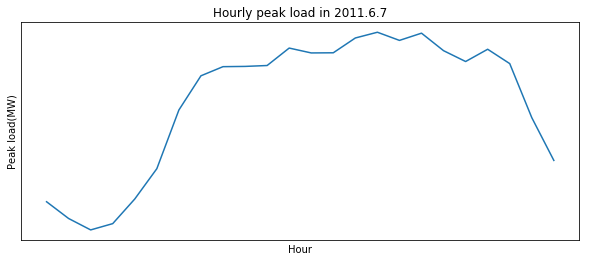

In [25]:
print('Shape of an array which contains hourly peak load at 2011.6 = ', eload['11-6'].shape) 
# shape of eload['11-6']
# each row represents day, each column represents hour from 00:00 ~ 24:00

# To see hourly trends of peak load in a day,
print('Hourly peak load at 2011.6.7 = ', eload['11-6'][7-1])
plt.title('Hourly peak load in 2011.6.7')
plt.xlabel('Hour')
plt.ylabel('Peak load(MW)')
plt.plot(eload['11-6'][7-1])
plt.xticks([])
plt.yticks([])
plt.show()

To see monthly trends, plot daily peak loads for each years.

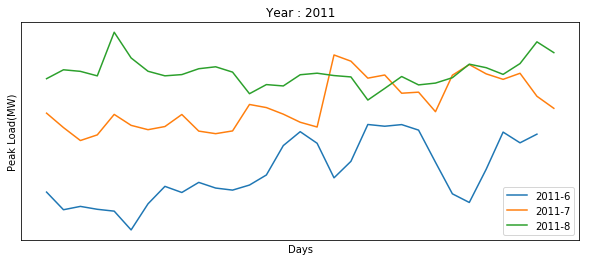

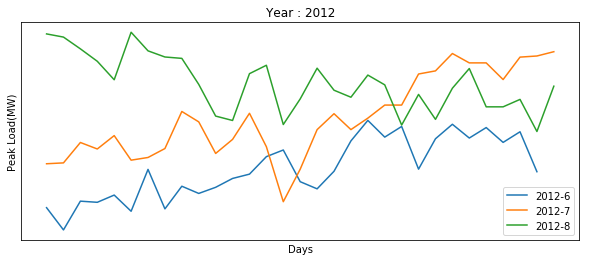

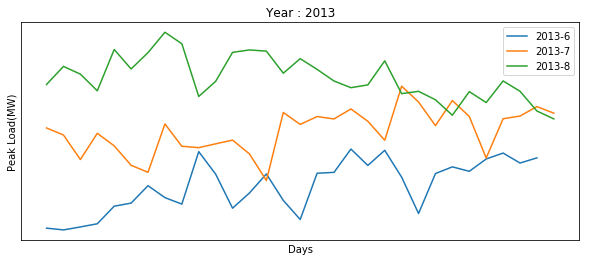

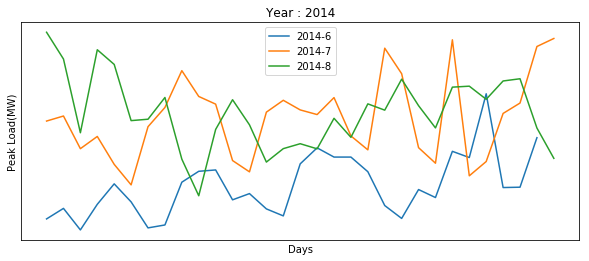

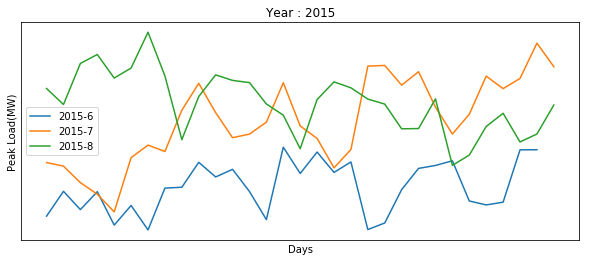

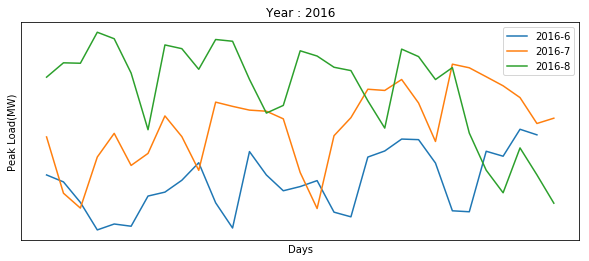

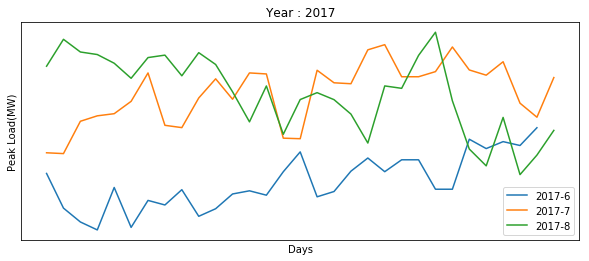

In [26]:
for idx, val in enumerate(eload):
    if idx % 3 == 0:
        plt.figure()
    plt.plot((np.max(np.array(eload[val]).astype(np.float), axis = 1)), label = str(20)+str(val))
    plt.title('Year : ' + str(idx//3 + 2011))
    plt.xlabel('Days')
    plt.ylabel('Peak Load(MW)')
    plt.legend()
    plt.xticks([])
    plt.yticks([])
plt.show()

## Factors which affect peak load
Since peak load heavily depends on the cooling load, factors with respect to the operation of air conditioner have to be considered to predict future peak load. Also, there are usually more electricity consumption during weekdays. Thus, elements below are going to be main factors to predict the date of yearly peak load - **daily peak load of yesterday**, **average temperature** of the day, **maximum temperature** of the day, **average humidity of the day, the number of passenger**(if necessary) who come to airport during the day, **days of the week**

### Load Datasets

- peak load per hour during the day, treands of the cooling load (from our SCADA system)

- average temperature during the day at Incheon Airport (from [Aviation Meteorological Office](http://amo.kma.go.kr/eng/html/main/main.jsp))

- maximum temperature during the day at Incheon Airport (from [Aviation Meteorological Office](http://amo.kma.go.kr/eng/html/main/main.jsp))

- average humidity during the day at Incheon Airport (from [Aviation Meteorological Office](http://amo.kma.go.kr/eng/html/main/main.jsp))

- the number of passenger during the day (from [Incheon International Airport Corporation : Research Institute](https://www.airport.kr/co/en/cpr/statisticCategoryOfDay.do))

- days of week (Mon ~ Sun)

In [27]:
# Re-load peak load data processed above
with open('./datasets/electrical_load/eload.pickle', 'rb') as f:
    eload = pickle.load(f)

# Load peak load of yesterday
with open('./datasets/electrical_load/prev_eload.pickle', 'rb') as f:
    prev_eload = pickle.load(f)

In [28]:
# Load weather data
""" wether datasets consist of three componensts : daily average temperature, maximum temperature, average 
    humadity in summer season (June ~ Aug) from 2011 ~ 2017, shape of each month : (the number of days, 3)  """
with open('./datasets/temperature/weather2.pickle', 'rb') as f:
    weather = pickle.load(f)

In [29]:
# Load passenger data in summer season(Jun ~ Aug) from 2011 ~ 2017
with open('./datasets/passenger/passenger.pickle', 'rb') as f:
    passenger = pickle.load(f)

In [30]:
# Load day (mon:1- sun:7) data in summer season(Jun ~ Aug) from 2011 ~ 2017
with open('./datasets/day/day.pickle', 'rb') as f:
    day = pickle.load(f)

### Data pre-processing for training
Arrange above datasets together in a dictionary. Each row indicates date and each column consists of weather, peak loads of yesterday, the number of passenger, index of the day, daily peak load of today, hourly peak load of today.

In [31]:
# Horizontally stack each dataset. shape (N, 31)
X_total = {}
for idx, val in enumerate(eload):
    X_total[str(val)] = np.hstack(( prev_eload[str(val)].reshape(-1,1), weather[str(val)][:, 0:2],  day[str(val)].reshape(-1,1), weather[str(val)][:, 2].reshape(-1, 1), passenger[str(val)].reshape(-1,1), np.amax(eload[str(val)], axis = 1).reshape(-1,1), eload[str(val)]))

In [32]:
""" Use weather and peak loads of current day and previous day, day index, the number of passenger data for training 
    linear regression model or neural nets. Normalize data through zero axis, make sure data in each column is zero-
    - centered except for the element which represents day index, Training data only during weekdays since weekly peak
    never happens during weekends """

X_train = {}
y_train = {}
for i in X_total:
    X = X_total[str(i)][:, 0:6]             # weather, daily peak of yesterday, passenger, day index
    y = X_total[str(i)][:, 6].reshape(-1,1) # daily peak of today
    X_train[str(i)] = X
    y_train[str(i)] = y


# split data into two parts, weekdays and weekends    
    
for key, arr in X_train.items():
    if key == '11-6':
        X = arr
    else:
        X  = np.vstack((X, arr))
        
for key, arr in y_train.items():
    if key == '11-6':
        y = arr
    else:
        y = np.vstack((y, arr))
        
idx_wd = X[:,3] < 6 #indicies of weekdays
idx_wk = X[:,3] > 5 #indicies of weekdays

X_train_wd_act = X[idx_wd]
total_mean = np.mean(X_train_wd_act, axis = 0)
total_std = np.std(X_train_wd_act,axis = 0)
X_train_wd = (X_train_wd_act - np.mean(X_train_wd_act, axis = 0))/np.std(X_train_wd_act,axis = 0) 
X_train_wk = X[idx_wk]
y_train_wd = y[idx_wd]
y_train_wk = y[idx_wk]

# Only weekdays will be used for training and forecasting
# Devide data into three parts : training sets, val sests, test sets - 5:2:2

arr = np.arange(X_train_wd.shape[0])
np.random.shuffle(arr)
X_train_WD = X_train_wd[arr][0:250]
X_val_WD = X_train_wd[arr][250:350]
X_test_WD = X_train_wd[arr][350:]
y_train_WD = y_train_wd[arr][0:250]
y_val_WD = y_train_wd[arr][250:350]
y_test_WD = y_train_wd[arr][350:]


# put data in a dictionary 'data'
data = {}
data['X_train'] = X_train_WD
data['y_train'] = y_train_WD
data['X_val'] = X_val_WD
data['y_val'] = y_val_WD
data['X_test'] = X_test_WD
data['y_test'] = y_test_WD

### There are three main ways to forecast peak load
1. Linear regression or shallow neural nets(two layer nets)
2. Time series analysis (movinv average mean) in combination with linear regression (or two layer nets)
3. RNN(recurrent neural nets) or LSTM(long short term memory)

### 1. Day-ahead peak load forecasting using linear regression model or shallow neural nets

####  1) Multivariate Linear Regression

$$ \hat{y}= X_1w_1 + X_2w_2 + X_3w_3 + X_4w_4 + X_5w_4 + X_6w_6 + b $$ 

- $X_1$ : daily peak load of yesterday, $X_2$ : avg temperature, $X_3$ : max temperature, $X_4$ : avg humadity, $X_5$ : the number of passenger, $X_6$ : day index
- $\hat{y}$ : predicted daily peak load
 
####  2) Shallow Neural Nets(two layer net)
Use same input above and apply non-linear activation function, such as sigmoid or relu, after each linear transformation. $\hat{y}$ can be different with respect to the number of nodes in hidden layer.

Architecture:
* affine forward(linear transformation), sigmoid or relu(activation function)
* affine forward(linear transformation)
![caption](two_layer_net.png)

### Each steps for training datasets

 - Weight Initialization : use Xavier Initialization
 - Define Loss and compute gradients : use L2 regularization and least square error as a loss function
 - Optimize using gradient descent : use vanilla Gradient Descent with full batch, no update rule since the number of data is small
 - Define function for cheking accuracy (or error) and helper function for training datasets : use mean square error to check accuracy and arrange all together to run training

**(To change setting,  modify load_forecast.py and solver.py)**

#### [1] Check loss and gradients for each model. 

In [33]:
model_test = linear_regression(input_dim = 6, reg = 0.01)
loss1, grads1 = model_test.loss(X_train_WD, y_train_WD)
print('loss, grads for linear regression = ', loss1, grads1)


model2_test = two_layer_net(input_dim = 6, hidden_dim = 2, activation = 'relu', reg = 0.01)
loss2, grads2 = model2_test.loss(X_train_WD, y_train_WD)
print('loss, grads for two layer nets = ', loss2, grads2)

loss, grads for linear regression =  2816.9437869060125 {'W1': array([[-6.43548117],
       [-9.19540246],
       [-9.155381  ],
       [-3.02117962],
       [-1.73569976],
       [-8.29354072]]), 'b1': array([-74.2533891])}
loss, grads for two layer nets =  2792.6907249474457 {'W2': array([[-12.16029971],
       [-44.51464245]]), 'b2': array([-73.87048854]), 'W1': array([[ 18.27301332,  -4.85650088],
       [ -4.23760199,  -6.94911295],
       [-12.21211998,  -8.34254483],
       [  3.60684913,   2.10317828],
       [ 27.37984869,   4.3631869 ],
       [  5.02595841,  -1.20502656]]), 'b1': array([-52.08880129, -10.9458464 ])}


#### [2] Training datasets using solver.py
##### 1. Mulivariate linear regression

In [34]:
# Hyper-parameter tuning section
reg = [1e-1, 1e-2, 1e-3]
lr = [1e-3, 1e-4]
best_acc = [100]
val_his = []

for rg in reg:
    for l in lr:
        model = linear_regression(input_dim = 6, reg = rg)
        solver1 = solver(model, data, batch_size = 300, print_every = 10000, iteration = 40000, 
                         verbose = True, learning_rate = l, update_rule = 'sgd')
        solver1.train()
        acc = solver1.check_accuracy(X=data['X_val'], y = data['y_val'])
        print('reg, lr = ', (rg, l))
        if acc[0] <= best_acc[0]:
            best_acc = acc
            best_model = model
            best_param = (rg, l)
            
print('best_hyper_param = ', best_param)
print('best_acc = ', acc)
        

(Iteration 1 / 30000) loss: 2806.835738
(Iteration 10001 / 30000) loss: 9.915103
(Iteration 20001 / 30000) loss: 10.236238
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [2.4372570868826635, 3.314512623328853, 3.2307714647805117] [2.7319093200356224, 3.8077488345770676, 3.503587411789897]
reg, lr =  (0.1, 0.001)
(Iteration 1 / 30000) loss: 2882.943279
(Iteration 10001 / 30000) loss: 10.467001
(Iteration 20001 / 30000) loss: 11.758058
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [2.438127435946152, 3.316441952902267, 3.231893068696323] [2.7305844242501065, 3.8054654621900297, 3.5016612412994292]
reg, lr =  (0.1, 0.0001)
(Iteration 1 / 30000) loss: 2751.160794
(Iteration 10001 / 30000) loss: 4.218435
(Iteration 20001 / 30000) loss: 3.731024
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [1.9557991543530784, 2.772999044340745, 2.580249111275827] [2.1724861832059723, 2.959594008095392, 2.783027386968245]
reg, lr =  (0.01, 0.001)
(Iteration 1 / 30000) loss: 2963

Predict peak load for test_sets and compare to average difference rate between adjacent days

test_error [mae(mw), rmse(mw), mape(%)] of linear regression =  [1.9691656025847961, 2.6646030219714443, 2.593644341595621]
avgerage[mae(mw), rmse(mw), mape(%) between adjacent days =  2.374481903726708 3.270228092520299 3.1966184719937445


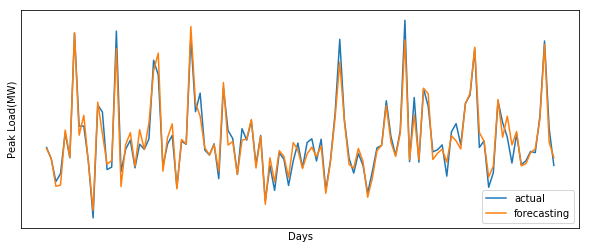

In [35]:
best_solver = solver(model = best_model, data = data)
test_error = best_solver.check_accuracy(X = data['X_test'], y = data['y_test'])
pred_val = best_model.loss(X = data['X_test'], y = None)
print('test_error [mae(mw), rmse(mw), mape(%)] of linear regression = ', test_error )

adj_mae = np.mean((np.abs((X[:, 0].reshape(-1, 1) - y))))
adj_rmse = np.sqrt(np.mean(np.square(X[:,0].reshape(-1,1)-y)))
adj_mape = np.mean(np.abs(X[:,0].reshape(-1,1)-y)/y)*100
print('avgerage[mae(mw), rmse(mw), mape(%) between adjacent days = ', adj_mae, adj_rmse, adj_mape)

# plot comparison between forecasted value and real value on the graph
actual = y_test_WD
plt.plot(actual, label = 'actual')
plt.plot(pred_val, label = 'forecasting')
plt.xlabel('Days')
plt.ylabel('Peak Load(MW)')
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

##### 2. Two layer neural nets

In [36]:
# Hyper-parameter tuning section
reg = [1e-3, 1e-2, 1e-1]
lr = [1e-3, 1e-2]
best_acc2 = [100]
val_his = []

for rg in reg:
    for l in lr:
        model2 = two_layer_net(input_dim = 6, hidden_dim = 5, activation = 'relu', reg = rg)
        solver2 = solver(model2, data, batch_size = 300, print_every = 10000, iteration = 30000, 
                         verbose = True, learning_rate = l)
        solver2.train()
        
        acc2 = solver2.check_accuracy(X=data['X_val'], y = data['y_val'])
        print('reg, lr = ', (rg, l))
        if acc2[0] <= best_acc2[0]:
            best_acc2 = acc
            best_model2 = model2
            best_param2 = (rg, l)
            
print('best_hyper_param = ', best_param2)
print('best_acc = ', acc2)

(Iteration 1 / 30000) loss: 2933.459077
(Iteration 10001 / 30000) loss: 2.880511
(Iteration 20001 / 30000) loss: 3.011916
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [1.7990686469979222, 2.4988562389706663, 2.3681978776185013] [2.2329486449815077, 3.065233362905974, 2.88036333095421]
reg, lr =  (0.001, 0.001)
(Iteration 1 / 30000) loss: 2841.196842
(Iteration 10001 / 30000) loss: 3.335919
(Iteration 20001 / 30000) loss: 4.324850
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [1.8815546686401228, 2.614242316027669, 2.4748504746714763] [2.2507686589404132, 3.0539745074841194, 2.865922561839233]
reg, lr =  (0.001, 0.01)
(Iteration 1 / 30000) loss: 2787.550133
(Iteration 10001 / 30000) loss: 3.745547
(Iteration 20001 / 30000) loss: 3.570709
(Epoch(Iteration) 30000 / 30000)
train acc, val_acc  =  [1.8557419828822734, 2.590132096265668, 2.4349550971521876] [2.171872875877643, 2.927168924344283, 2.784050709062]
reg, lr =  (0.01, 0.001)
(Iteration 1 / 30000) loss: 2795.048

Predict peak load for test_sets and compare to average difference rate between adjacent days

test_error of two layer nets =  [2.0681393831654056, 2.8016998907241515, 2.7164550543466923]
avgerage mae(mw), rmse(mw), mape(%) between adjacent days =  2.374481903726708 3.270228092520299 3.1966184719937445


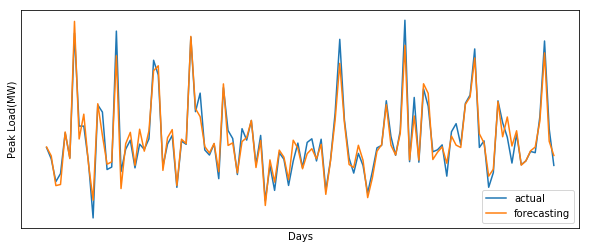

In [37]:
best_solver2 = solver(best_model2, data)
test_error = best_solver2.check_accuracy(X = data['X_test'], y = data['y_test'])
pred_val = best_model2.loss(X = data['X_test'], y = None)
print('test_error[mae(mw), rmse(mw), mape(%)] of two layer nets = ', test_error )

print('avgerage mae(mw), rmse(mw), mape(%) between adjacent days = ', adj_mae, adj_rmse, adj_mape)

# plot comparison between forecasted value and real value on the graph
actual = y_test_WD
plt.plot(actual, label = 'actual')
plt.plot(pred_val, label = 'forecasting')
plt.xlabel('Days')
plt.ylabel('Peak Load(MW)')
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

### 2. Day-ahead peak load forecasting using hybrid model

Use traditional time series analysis - moving average mean - to compute standard demand in combination with either multivariate linear regression or two-layer neural nets to predict daily peak load.

$$ \hat{L} = \bar{L} + \{{f(\hat{W}) - f(\bar{W})}\}\times \frac{\bar{L}}{f(\hat{W})}   $$

- $ \hat{L} $ : prediction value of peak load
- $ \bar{L} $ : standard demand of peak load
- $ f(x) $ : regression model (or neural nets) of standard demand
- $ \hat{W} $ : prediction weather value of standard demand
- $ \bar{W} $ : standard weather value of standard demand


####  Moving Average Mean
$$ \bar{L} = \sum_{k=1}^n w_{k} L_{k}
$$
- $ \bar{L} $ : standard demand of peak load (or wether)
- $ k $ : the number of reference days
- $ w_{k} $ : weight of reference day, the value is proportional to the similarity of the condition of weather with the day which we want to predict
- $ L_{k} $ : peak load of reference day (or wether)


##### Calculate weights to compute Standard demand
- Standard demand of peak load
$$ w_{k} = \frac{\{1+max(D_{f}-D_{1}, \cdots, max(D_{f}-D_{n})\} - (D_{f}-D_{k})}{\sum_{k=1}^{n}[\{1+max(D_{f}-D_{1}, \cdots, max(D_{f}-D_{n})\}-(D_{f}-D_{k})]}$$
 - $ D_{f} $ : date to forecast, $D_{k} $ :  k th date of reference

- standard demand of wether(average and maximum temperature, humadity)
$$ w_{k} = \frac{\sum_{k=1}^{n} \Delta\bar{W_{k}} - \Delta\bar{W_{k}} }{\sum_{k=1}^{n}(\sum_{k=1}^{n} \Delta\bar{W_{k}} - \Delta\bar{W_{k}})}, \Delta\bar{W_{k}} = |W_{f} - W_{k}| $$
 - $ W_{f} $  : temperature or humadity of forecasting day, $ W_{k} $ : k th temperature or humadity of reference


#### [1] Define standart demand of peak load and wether for a day

In [38]:
def compute_std_demand(month, day):
    """ compute standard demand of peak load and 
        wether for a day, using moving average mean """
    
    date = day - 1
    
    diff = np.abs((month - month[date])[:, 1]) + 2.5*np.abs((month - month[date])[:, 2]) 
    # define distance to find reference day which has similar wether condition (avg temp, max temp)
    # give extra weight to the difference of max temperature    
    
    diff_sort = np.argsort(diff)
    mark = 0
    idx_list = []
    if month[date, 3] == 6 or month[date, 3] == 7:
        pass   # Don't refer to weekends
        
    
    for i in diff_sort:  # collect indicies of similar days
        if i >= date:
            continue
    
        else:
            if month[i, 3] == 6 or month[i, 3] == 7:
                pass
            elif date - i <= 15:    # references should be made within two weeks
                idx_list.append(i)
                mark += 1
                if mark == 3:       # refer to three days for computing standard demand
                    break
    
    # compute standard load demand : hourly peak load demand, 24 figures (00~24) for a day
    idx_list = np.array(idx_list)
    diff2 = date - idx_list
    diff_rate = (1+np.amax(diff2)) - diff2
    diff_rate = diff_rate / np.sum(diff_rate, axis = 0)
    std_load = diff_rate[0]*month[idx_list[0], 7:31] + diff_rate[1]*month[idx_list[1], 7:31] + diff_rate[2]*month[idx_list[2], 7:31]
    
    # compute standard temperature, humadity demand : daily standard temperature, humadity
    diff3 = np.abs(month[idx_list, 1] - month[date, 1])  + 2.5*np.abs(month[idx_list, 2] - month[date, 2])
    diff4 = np.sum(diff3) - diff3
    diff_rate2 = diff4 / np.sum(diff4)
    std_temp = diff_rate2[0]*month[idx_list[0],[1,2,4]] + diff_rate2[1]*month[idx_list[1],[1,2,4]] + diff_rate2[2]*month[idx_list[2],[1,2,4]]
    
    return std_load, std_temp

#### [2] Compute error(mae, rmse, mape) for a month.

In [39]:
def compute_error(x, prev_x, model):
    """compute error rate for a month, training model(regression, neural nets) for each hour - result in 24 different models
       input : current month, previous month, model (regression or two-layer nets)
       outpout : avgerage error for a month, prediction of daily peak, actual dailiy peak, time_difference betweent prediction 
                 and actual peak load, whole prediction of hourly peak   """
       
    predict_his = []
    real_his = []
    diff_his = []
    time_his = []
    add_len = len(prev_x)
    
    mean = np.mean(prev_x, axis = 0) # compute mean, std for a previous month in advance
    std = np.std(prev_x, axis = 0)
    
    idx = prev_x[:, 3] < 6     #rule out weekends
    x_train = prev_x[idx]
    idx2 = x[:, 3] < 6
    x_val = x[idx2]
    X_train = ((x_train - mean) / std)[:, [1,2,4]]    # input dim = 3, [max temp, avg temp, humadity]
    Y_train = prev_x[idx][:, 7:].reshape(-1, 24)
    X_val = ((x_val - mean) / std)[:, [1, 2,4]]
    Y_val = x[idx2][:, 7:].reshape(-1, 24)
    
     
    hourly_model = {}  
    for j in range(24): # train regression (or neural networks) model for each hour in dataset of previous month
        y_train = Y_train[:, j].reshape(-1, 1)
        y_val = Y_val[:, j].reshape(-1, 1)
        dataset={} 
        dataset['X_train'] = X_train
        dataset['y_train'] = y_train
        dataset['X_val'] = X_val
        dataset['y_val'] = y_val
        dataset['X_test'] = None
        dataset['y_test'] = None   
    
        if model == 'mvr':
            lim_model = linear_regression(input_dim = 3, reg = 1e-2)
            solver1 = solver(model = lim_model, data = dataset, batch_size = None, print_every = 5000, iteration = 20000, 
                            verbose = False, learning_rate = 1e-3)
            solver1.train()
            hourly_model[str(j)] = lim_model
            
        elif model == 'mlp':
            nn_model = two_layer_net(input_dim = 3, hidden_dim = 5, activation = 'relu', reg = 1e-2)
            solver2 = solver(model = nn_model, data = data, batch_size = None, print_every = 5000, iteration = 30000, 
                            verbose = False, learning_rate = 1e-3)
            solver2.train()
            hourly_model[str(j)] = nn_model
        
    
    for i in range(31):
        """Divide into two parts : 1~15, 16~31, To predict days in 1~15,
        concatenate previous month so that make reasonable refereces """
        if i < 15:
            new_x = np.concatenate((prev_x, x), axis = 0)  # concatenate previous month to refer past days
            new_x_norm = (new_x - mean) / std
            first_idx =  (np.where((new_x[add_len:, 3] < 6) == True)[0][0])  # save first index of weekend
            if new_x[i+add_len, 3] == 6 or new_x[i+add_len, 3] == 7:
                pass
            else:
                std_load, std_temp = compute_std_demand(new_x, i+1+add_len)
                predict_l = []
                real_l = []
                for j in range(24):            # train linear regression(or neural nets) for each hour
                    load = std_load[j]
                    
                    h_model = hourly_model[str(j)]
                    fw_hat = h_model.loss(X= new_x_norm[i+add_len, [1,2,4]].reshape(1, -1), y = None)
                    fw_bar = h_model.loss(X= ((std_temp - mean[[1,2,4]])/ std[[1,2,4]]).reshape(1, -1), y = None)
                    predict_load = load * (1+ (fw_hat - fw_bar)/fw_hat)

                    predict_l.append(float(predict_load))
                    real_l.append(new_x[i+add_len, 7+j])
                    
                    if j == 23:    # save the prediction and the acutal value of daily peak load 
                        predict_his.append(float(max(predict_l)))   
                        real_his.append(float(max(real_l)))
                        
                        mae = np.abs(float(max(predict_l)) - float(max(real_l)))
                        rmse = np.sqrt(np.mean(np.square(float(max(predict_l))-float(max(real_l)))))
                        mape = np.mean(np.abs((float(max(predict_l)) - float(max(real_l)))/float(max(real_l))))*100
                        
                        diff_his.append((mae, rmse, mape)) # save error rate of daily peak load
                        time_his.append(np.abs(np.argmax(np.array(predict_l)) - np.argmax(np.array(real_l))))  # compute distance between indicies
                        
                        if i == first_idx: # if i is first idx of weekends, assign value
                            prev_predict_l = np.array(predict_l)
                        else:
                            pred = np.vstack((prev_predict_l, np.array(predict_l))) # stack hourly peak load for a month
                            prev_predict_l = np.array(predict_l)  

            
        else:
            if x[i, 3] == 6 or x[i, 3] == 7:
                pass
            else:
                std_load, std_temp = compute_std_demand(x, i+1)
                predict_l = []
                real_l = []
                for j in range(24):  # train linear regression(or neural nets) for each hour
                    load = std_load[j]
                    h_model = hourly_model[str(j)]
                    fw_hat = h_model.loss(X= new_x_norm[i+add_len, [1,2,4]].reshape(1, -1), y = None)
                    fw_bar = h_model.loss(X= ((std_temp - mean[[1,2,4]])/ std[[1,2,4]]).reshape(1, -1), y = None)
                    predict_load = load * (1+ (fw_hat - fw_bar)/fw_hat)
                    
                    predict_l.append(float(predict_load))
                    real_l.append(new_x[i+add_len, 7+j])
                    
                    if j == 23: # save the prediction and the acutal value of daily peak load 
                        predict_his.append(float(max(predict_l)))
                        real_his.append(float(max(real_l)))
                        
                        mae = np.abs(float(max(predict_l)) - float(max(real_l)))
                        rmse = np.square(float(max(predict_l)-float(max(real_l))))
                        mape = np.mean(np.abs((float(max(predict_l)) - float(max(real_l)))/float(max(real_l))))*100
                        
                        diff_his.append((mae, rmse, mape)) # save error rate of daily peak load
                        time_his.append(np.abs(np.argmax(np.array(predict_l)) - np.argmax(np.array(real_l))))  # compute distance between indicies
                        if i == first_idx:  # if i is first idx of weekends, assign value
                            prev_predict_l = np.array(predict_l)
                        else:
                            pred = np.vstack((prev_predict_l, np.array(predict_l))) # stack hourly peak load for a month
                            prev_predict_l = np.array(predict_l)   # Final dimension = (31, 24)
                        
    
    error = (np.mean((np.array(diff_his)[:, 0])), np.sqrt(np.mean((np.array(diff_his)[:, 1]))), np.mean((np.array(diff_his)[:, 2])))
    real_l = np.array(real_his)
    predict_l = np.array(predict_his)
    time_delay = np.array(time_his)
    return error, predict_l, real_l, time_delay, pred

#### [3] Plot yearly trends of preadiction and actual dailiy peak load

Error(mae(mw), rmse(mw), mape(%)) in 2011-7 =  (1.4245649879113227, 1.5470137365525694, 2.0612804779236726)
Time difference(h) in 2011-7 =  3.1904761904761907


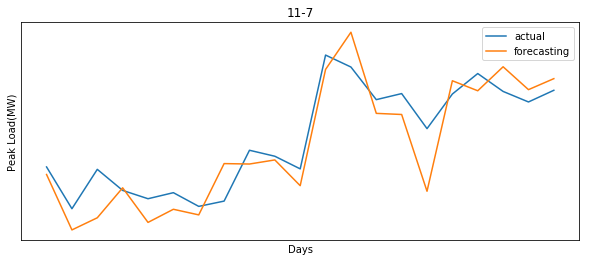

Error(mae(mw), rmse(mw), mape(%)) in 2011-8 =  (0.9465343240210605, 1.0767209851638946, 1.2951769806583473)
Time difference(h) in 2011-8 =  2.347826086956522


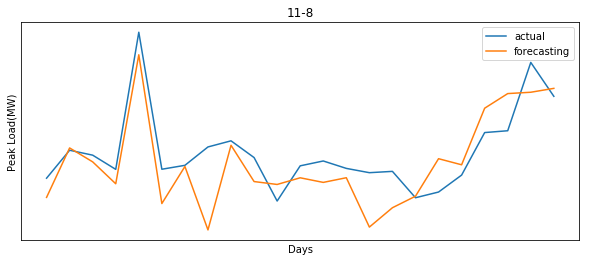

Error(mae(mw), rmse(mw), mape(%)) in 2012-7 =  (0.9063335312695102, 1.0956484470980294, 1.3120730946742647)
Time difference(h) in 2012-7 =  3.090909090909091


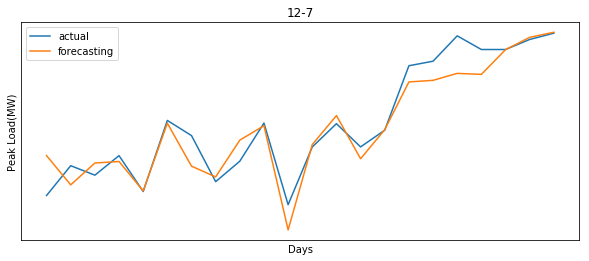

Error(mae(mw), rmse(mw), mape(%)) in 2012-8 =  (2.0895739433049867, 2.4754341727685714, 2.920419046060874)
Time difference(h) in 2012-8 =  3.391304347826087


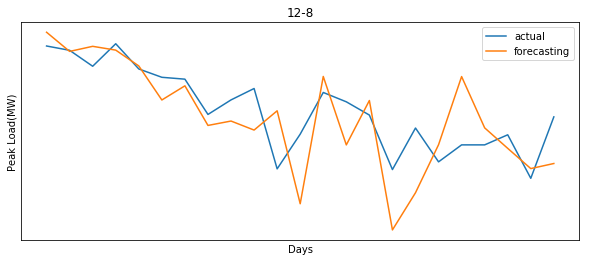

Error(mae(mw), rmse(mw), mape(%)) in 2013-7 =  (1.051156041322131, 1.1396924121744478, 1.5199192175121126)
Time difference(h) in 2013-7 =  2.0434782608695654


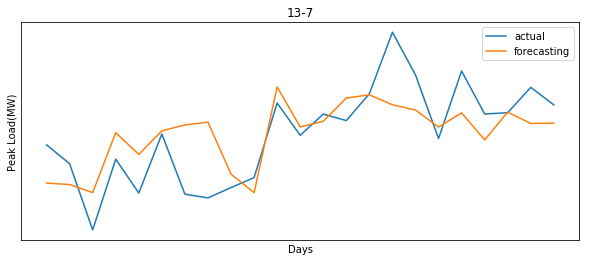

Error(mae(mw), rmse(mw), mape(%)) in 2013-8 =  (1.3354444434685604, 1.5466413553695584, 1.7968929264676468)
Time difference(h) in 2013-8 =  2.090909090909091


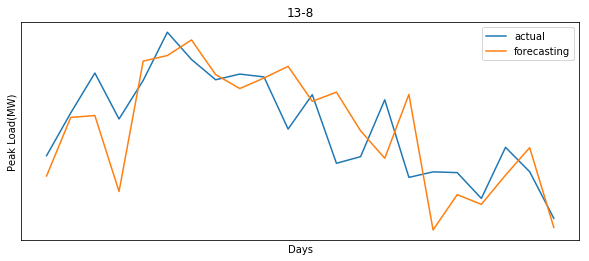

Error(mae(mw), rmse(mw), mape(%)) in 2014-7 =  (2.0352187425976926, 2.076463769149079, 2.7955827164532963)
Time difference(h) in 2014-7 =  2.1739130434782608


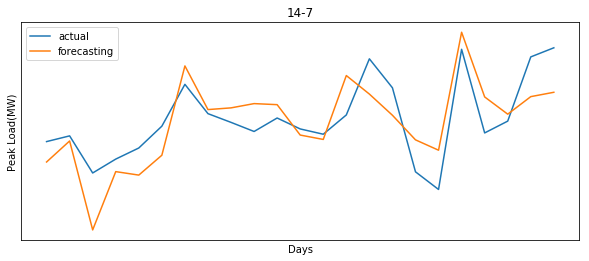

Error(mae(mw), rmse(mw), mape(%)) in 2014-8 =  (1.6009572238080407, 1.8684025568573468, 2.1946226992720015)
Time difference(h) in 2014-8 =  2.7142857142857144


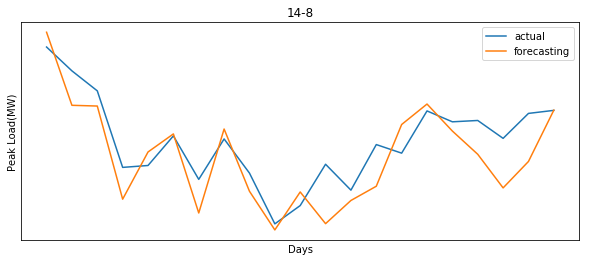

Error(mae(mw), rmse(mw), mape(%)) in 2015-7 =  (1.438850768254453, 1.6646004072537939, 1.9203265505032865)
Time difference(h) in 2015-7 =  1.8695652173913044


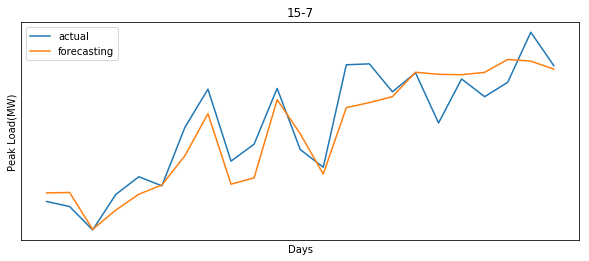

Error(mae(mw), rmse(mw), mape(%)) in 2015-8 =  (1.4109521037300545, 1.7358186513279728, 1.8965493014710493)
Time difference(h) in 2015-8 =  3.0952380952380953


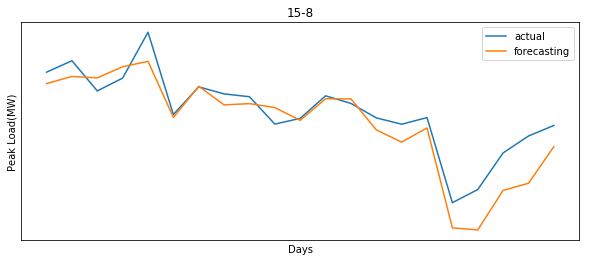

Error(mae(mw), rmse(mw), mape(%)) in 2016-7 =  (1.502229229734101, 1.4823517003765525, 1.8584062591541723)
Time difference(h) in 2016-7 =  1.5238095238095237


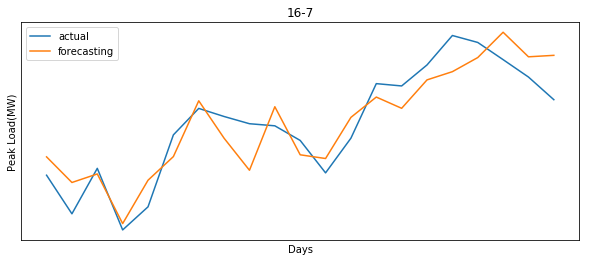

Error(mae(mw), rmse(mw), mape(%)) in 2016-8 =  (1.9481742621587659, 2.013314592275088, 2.325512850889554)
Time difference(h) in 2016-8 =  1.173913043478261


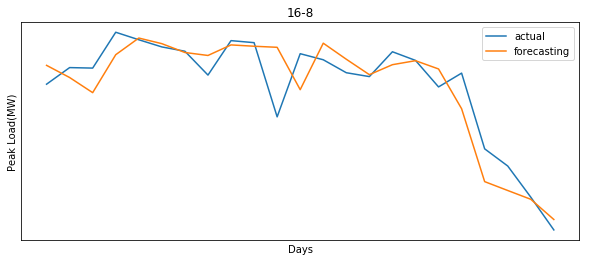

Error(mae(mw), rmse(mw), mape(%)) in 2017-7 =  (2.4608215469031713, 2.1787912065998283, 2.372059375829216)
Time difference(h) in 2017-7 =  1.8095238095238095


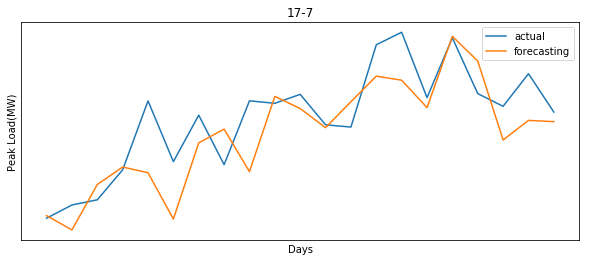

Error(mae(mw), rmse(mw), mape(%)) in 2017-8 =  (2.3844722778493614, 3.084831043670832, 2.329457737029356)
Time difference(h) in 2017-8 =  1.3043478260869565


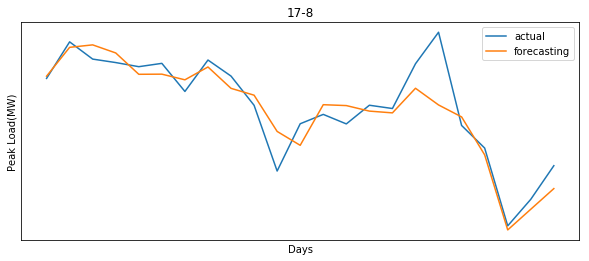

Error(on average) from 2011 to 2017 =  (1.6096631018809437, 1.7846946454741115, 2.042734230992775)
Error(on average) from 2011 to 2016 =  (1.474165800131723, 1.643508565530575, 1.9913968434200229)


In [40]:
count = 0
error_his = []
pred_total = {}
for key, arr in X_total.items():
    count += 1
    if count % 3 == 1:
        prev_arr = arr
        
    elif count % 3 == 2:
        error, pred_l, real_l, time_delay, pred_24 = compute_error(arr, prev_arr, model='mvr')
        pred_total[key] = pred_24
        prev_arr = arr
        error_his.append(error)
        
        print('Error(mae(mw), rmse(mw), mape(%)) in 20'+ str(key) + ' = ', error)
        print('Time difference(h) in 20' + str(key) + ' = ', np.mean(time_delay))
        plt.figure()
        plt.plot(real_l, label = 'actual')
        plt.plot(pred_l, label = 'forecasting')
        plt.title(str(key))
        plt.legend()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('Days')
        plt.ylabel('Peak Load(MW)')
        plt.show()
        
        
    else:
        error, pred_l, real_l, time_delay, pred_24 = compute_error(arr, prev_arr,model='mvr')
        pred_total[key] = pred_24
        error_his.append(error)
        
        print('Error(mae(mw), rmse(mw), mape(%)) in 20'+ str(key) + ' = ', error)
        print('Time difference(h) in 20' + str(key) + ' = ', np.mean(time_delay))
        plt.figure()
        plt.plot(real_l, label = 'actual')
        plt.plot(pred_l, label = 'forecasting')
        plt.title(str(key))
        plt.legend()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('Days')
        plt.ylabel('Peak Load(MW)')
        plt.show()
        
print('Error(on average) from 2011 to 2017 = ', (np.mean(np.array(error_his)[:,0]), np.mean(np.array(error_his)[:,1]), np.mean(np.array(error_his)[:,2])))
print('Error(on average) from 2011 to 2016 = ', (np.mean(np.array(error_his)[:-2, 0]), np.mean(np.array(error_his)[:-2, 1]), np.mean(np.array(error_his)[:-2, 2])))

### Future work : Day-ahead peak load forecasting using RNN or  LSTM
 - RNN (Recurrent Neural Networks)
 - LSTM (Long Term Short Memory)

### References

 - 이학노, 한진현, 이명훈(2010), 전력피크의 추정 및 예측에 대한 연구 (http://www.keei.re.kr/web_keei/d_results.nsf/0/CC3B71E82029F1A7492577BC00031237)
 - 전력거래소(2011), 단기 전력수요 예측 기법 및 적용방안에 관한 연구(https://www.kpx.or.kr/www/downloadBbsFile.do?atchmnflNo=16277)
 - 전력거래소(2015), 실시간 수요예측 기법 개발 및 온라인 수요예측 방안 연구(https://www.kpx.or.kr/www/downloadBbsFile.do?atchmnflNo=16117)
 - 한국전력공사 전력연구원(2015), 수요예측 기반의 수요관리 통합 포털 개발(https://www.kepri.re.kr:20808/keeping_file/notice_item/20151014135532.pdf)
 - Filippo Maria Bianchi(2017), An overview and comparative analysis of Recurrent Neural Networks for Short Term Load Forecasting (https://arxiv.org/abs/1705.04378v2)
 - Cristian Vasar(2018), Short Term Electric Load Forecast with Artificial Neural Networks (https://arxiv.org/abs/1804.06660v1)




 